# KNN Exercise

![iris](images/iris.jpg)

We are going to use the famous **iris data set** again. 

The dataset consists of four attributes, which can be used to distinguish different iris species: 
* sepal-width
* sepal-length
* petal-width 
* petal-length. 


The task is to predict the class to which these plants belong. There are three classes in the dataset: **Iris-setosa, Iris-versicolor and Iris-virginica.** 

Further details of the dataset are available here.
https://scikit-learn.org/stable/auto_examples/datasets/plot_iris_dataset.html

## Task

1. Please import and preprocess the data (as far as it's necessary). Afterwards split it in a train and test set, fit a KNN model and make predictions on the test set. The last step is to evaluate your model. Try to also scale your data and fit the model to the unscaled and scaled data. Can you see a difference in performance?

2. Please also calculate the accuracy for K values of 1 to 40. In each iteration the accuracy for the predicted values of the test set is calculated and the result is appended to an error list.
The next step is to plot the aMccuracy values against K values.

In [24]:
# import libraries 

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from itertools import combinations 
from scipy.stats import zscore

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, recall_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [3]:
# unzipped data folder in terminal
# import iris dataset

df = pd.read_csv('data/iris.csv')

In [5]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [ ]:
df.info()
#

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [7]:
df.species.value_counts()

species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

In [8]:
df.isna().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [22]:
# sns.pairplot(df, hue='species')

In [18]:
# Change values for malignant from 0 to 1 
# X = df.drop(columns='species')
y = df['species']

X = df[['petal_length', 'petal_width', 'sepal_length', 'sepal_width']]

In [19]:
# Split data into train and test set
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1)

Accuracy: 1.0
Recall: 1.0
--------------------------------------------------


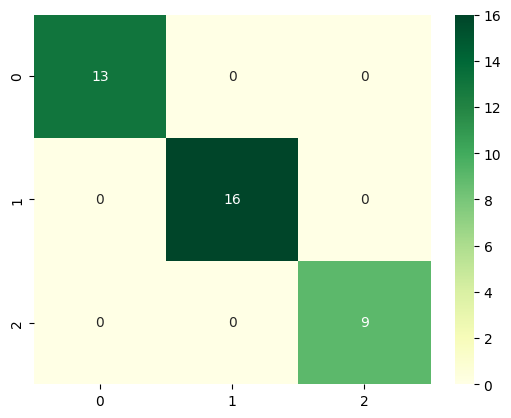

In [29]:
# Train model
knn_m1 = KNeighborsClassifier()
knn_m1.fit(X_train, np.ravel(y_train))


# Predict on test set
y_m1_pred = knn_m1.predict(X_test)

# Print accuracy score 
print("Accuracy:", accuracy_score(y_test, y_m1_pred).round(2))
print("Recall:", recall_score(y_test, y_m1_pred, average="macro").round(2))
print("-----"*10)

# Print confusion matrix
sns.heatmap(confusion_matrix(y_test,y_m1_pred), annot=True, cmap='YlGn');



In [31]:
#define which columns to scale
col_scale = X.columns

# Scaling with standard scaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train[col_scale])
X_test_scaled = scaler.transform(X_test[col_scale])

# Concatenating scaled and dummy columns
X_train_preprocessed = np.concatenate([X_train_scaled, X_train.drop(col_scale, axis=1)], axis=1)
X_test_preprocessed = np.concatenate([X_test_scaled, X_test.drop(col_scale, axis=1)], axis=1)

Accuracy: 0.97
Recall: 0.98
--------------------------------------------------


<Axes: >

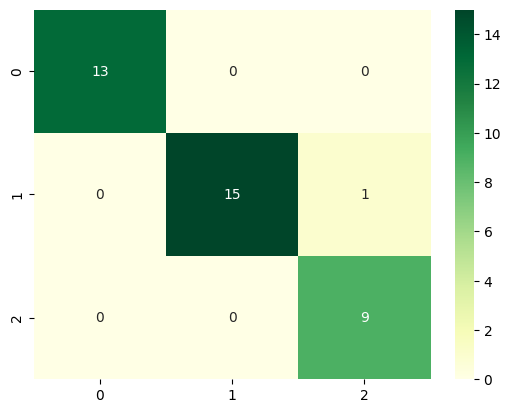

In [32]:
# Train model
knn_m2 = KNeighborsClassifier()
knn_m2.fit(X_train_preprocessed, np.ravel(y_train))


# Predict on test set
y_m2_pred = knn_m2.predict(X_test_preprocessed)

# Print accuracy score 
print("Accuracy:", accuracy_score(y_test, y_m2_pred).round(2))
print("Recall:", recall_score(y_test, y_m2_pred, average="macro").round(2))
print("-----"*10)

# Print confusion matrix
sns.heatmap(confusion_matrix(y_test,y_m2_pred), annot=True, cmap='YlGn')


---

# Task 2

Please also calculate the accuracy for K values of 1 to 40. In each iteration the accuracy for the predicted values of the test set is calculated and the result is appended to an error list.

The next step is to plot the accuracy values against K values.

In [76]:
X = df[['petal_length','petal_width']]

# 'petal_length', 'petal_width', 'sepal_length', 'sepal_width'

# Split data into train and test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, shuffle=True, stratify=y, random_state=1)

#define which columns to scale
col_scale = X.columns

# Scaling with standard scaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train[col_scale])
X_test_scaled = scaler.transform(X_test[col_scale])

# Concatenating scaled and dummy columns
X_train_preprocessed = np.concatenate([X_train_scaled, X_train.drop(col_scale, axis=1)], axis=1)
X_test_preprocessed = np.concatenate([X_test_scaled, X_test.drop(col_scale, axis=1)], axis=1)

In [77]:
acc_list = []

for k in range(40):
    # Train model
    knn_m2 = KNeighborsClassifier(n_neighbors=k+1, metric='euclidean')
    knn_m2.fit(X_train_preprocessed, np.ravel(y_train))


    # Predict on test set
    y_m2_pred = knn_m2.predict(X_test_preprocessed)
    acc_list.append(accuracy_score(y_test, y_m2_pred).round(2))

# acc_list

# # Print accuracy score 
# print("Accuracy:", accuracy_score(y_test, y_m2_pred).round(2))
# print("Recall:", recall_score(y_test, y_m2_pred, average="macro").round(2))
# print("-----"*10)

# # Print confusion matrix
# sns.heatmap(confusion_matrix(y_test,y_m2_pred), annot=True, cmap='YlGn')


<Axes: >

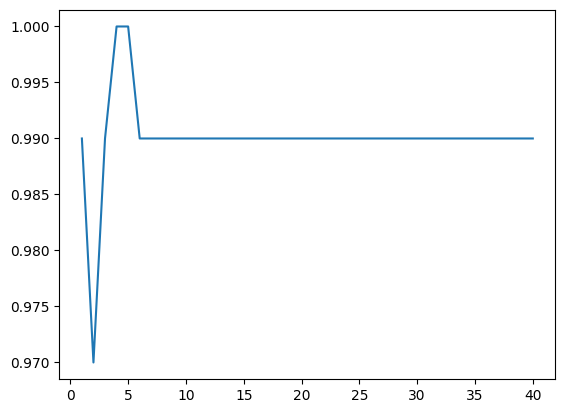

In [78]:
# plot the accuracy values against K values

sns.lineplot(x=np.arange(1, 41), y=acc_list)